In [1]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result, ChipGeometry

from PIL import Image
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [4]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
# root_path = "/Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac"
# root_path = "/Volumes/vangestel/Coco/ZeissData/pillartraining/"
# root_path = "/Volumes/vangestel/Coco/ZeissData/ICP/"



fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB7-04_S2.czi"
czi_name = "ICP16-03.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [133]:
channel = 1
time = 0
scene = 0
img, img_disp = get_frame(czi,time,channel,scene = scene)

In [134]:
result = align_chip_to_image(img, pixel_size_um=pixel_size["X"], debug=False, geom=ChipGeometry())

In [135]:
def select_roi(img):
#     roi, _ = get_roi_from_result(
#     result,
#     result['rotate_fn'](img) ,
#     region= "bottom",
#     pad_left_um=-2600.0,   # expand chip box leftward (µm)
#     pad_right_um=-500.0,  # expand chip box rightward (µm)
#     pad_top_um=-500.0,    # pad above & below main channel centre (symmetric)
#     pad_bottom_um= 1300
# )
    return img[:350,:1000]

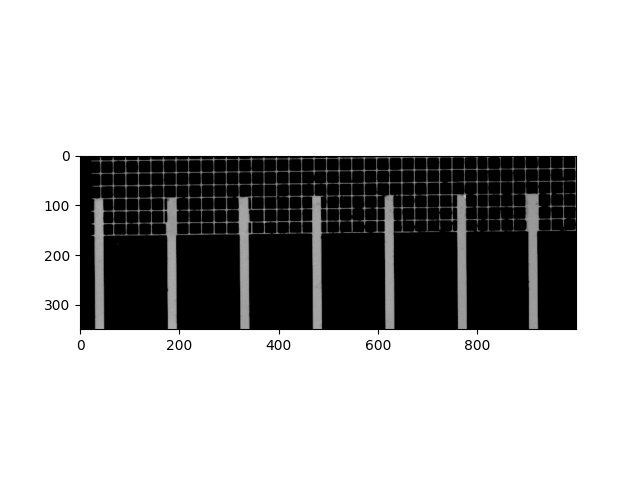

In [136]:

stretch_min = 50
stretch_max = 99.5
channel = 0
time = 0
img, img_disp = get_frame(czi,time,channel,gamma=0.45,stretch_min=stretch_min,stretch_max=stretch_max,scene=scene)
fig,ax = plt.subplots()
ax.imshow(select_roi(img_disp),cmap="gray")

Using channel 0 + channel 1 (normalised sum)
ch0+ch1 — Gaussian background removal + Otsu
  BG σ             : 300.0 µm  (109.3 px)
  Otsu threshold   : 0.1895
  Pillar area      : 516,338.5 µm²
  ROI area         : 2,635,033.0 µm²
  Coverage         : 19.60 %


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_92772/3238816592.py:49: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_obj_px)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_92772/3238816592.py:50: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller o

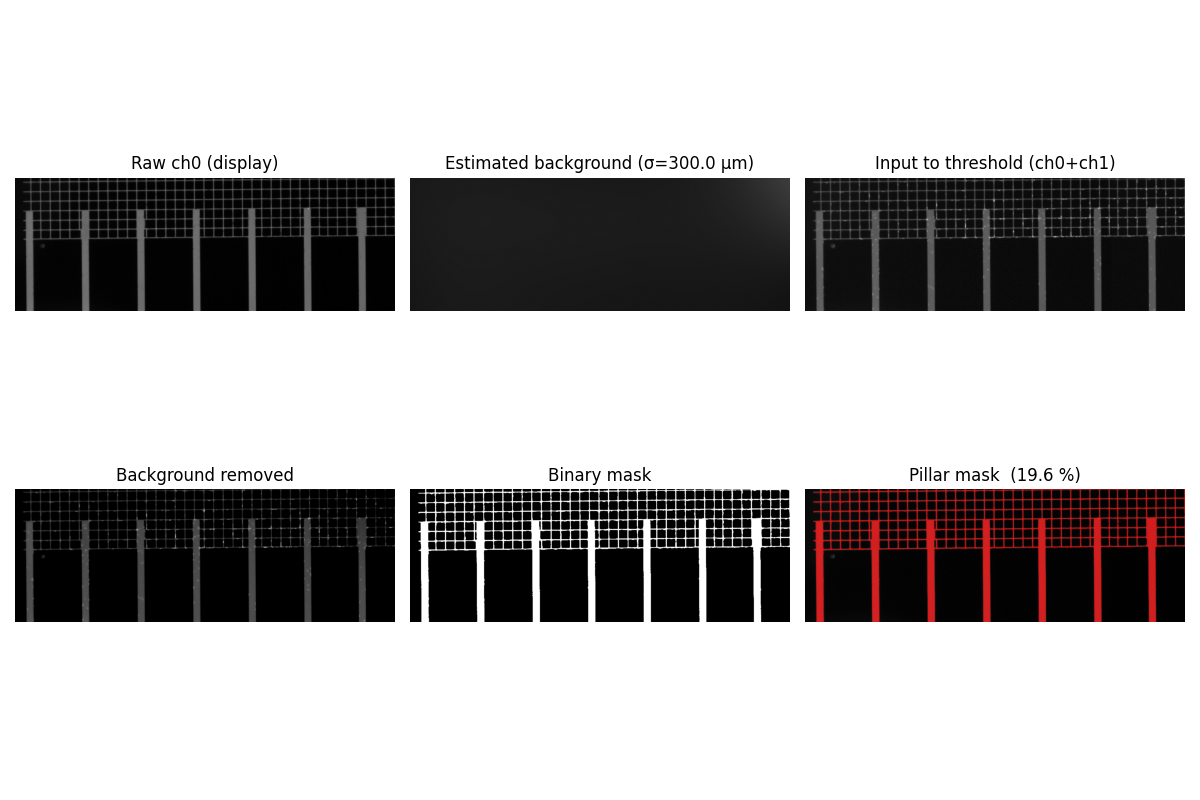

In [137]:
from skimage import exposure
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters ───────────────────────────────────────────────────────────────
channel          = 0
channel_add      = 1      # set to None to use channel 0 only; set to an int to sum ch0 + ch_add
time             = 5

BG_SIGMA_UM  = 300.0
MIN_OBJ_UM2  = 1000.0
MAX_HOLE_UM2 = 50.0

# ── Load & crop ───────────────────────────────────────────────────────────────
px_um = pixel_size["X"]
img_raw, img_disp = get_frame(czi, time, channel, gamma=1, stretch_min=1, stretch_max=99.5,scene=scene)
img_raw  = select_roi(img_raw.astype(float))
img_disp = select_roi(img_disp)

if channel_add is not None:
    img_raw2, _ = get_frame(czi, time, channel_add, gamma=1, stretch_min=1, stretch_max=99.5,scene=scene)
    img_raw2 = select_roi(img_raw2.astype(float))
    # Normalise each channel to [0,1] then sum and re-normalise
    norm0 = exposure.rescale_intensity(img_raw,  out_range=(0.0, 1.0))
    norm1 = exposure.rescale_intensity(img_raw2, out_range=(0.0, 1.0))
    img_norm = exposure.rescale_intensity(norm0 + norm1, out_range=(0.0, 1.0))
    print(f"Using channel {channel} + channel {channel_add} (normalised sum)")
else:
    img_norm = exposure.rescale_intensity(img_raw, out_range=(0.0, 1.0))
    print(f"Using channel {channel} only")

H, W = img_norm.shape

# ── Gaussian background removal ──────────────────────────────────────────────
bg_sigma_px = BG_SIGMA_UM / px_um
background  = gaussian(img_norm, sigma=bg_sigma_px, preserve_range=True)
bg_removed  = np.clip(img_norm - background, 0, None)
bg_removed  = exposure.rescale_intensity(bg_removed, out_range=(0.0, 1.0))

# ── Otsu threshold ───────────────────────────────────────────────────────────
otsu_thresh = threshold_otsu(img_norm)
binary = img_norm > otsu_thresh

# ── Morphological clean-up ────────────────────────────────────────────────────
min_obj_px  = max(1, int(np.round(MIN_OBJ_UM2  / px_um ** 2)))
max_hole_px = max(1, int(np.round(MAX_HOLE_UM2 / px_um ** 2)))
binary = remove_small_objects(binary, min_size=min_obj_px)
binary = remove_small_holes(binary,   area_threshold=max_hole_px)

# ── Measurement ───────────────────────────────────────────────────────────────
pillar_area_um2 = binary.sum() * px_um ** 2
roi_area_um2    = binary.size  * px_um ** 2
pillar_fraction = binary.mean()

ch_label = f"ch{channel}+ch{channel_add}" if channel_add is not None else f"ch{channel}"
print(f"{ch_label} — Gaussian background removal + Otsu")
print(f"  BG σ             : {BG_SIGMA_UM:.1f} µm  ({bg_sigma_px:.1f} px)")
print(f"  Otsu threshold   : {otsu_thresh:.4f}")
print(f"  Pillar area      : {pillar_area_um2:,.1f} µm²")
print(f"  ROI area         : {roi_area_um2:,.1f} µm²")
print(f"  Coverage         : {pillar_fraction * 100:.2f} %")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(img_disp, cmap="gray")
axes[0, 0].set_title("Raw ch0 (display)")

axes[0, 1].imshow(background, cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title(f"Estimated background (σ={BG_SIGMA_UM} µm)")

axes[0, 2].imshow(img_norm, cmap="gray", vmin=0, vmax=1)
axes[0, 2].set_title(f"Input to threshold ({ch_label})")

axes[1, 0].imshow(bg_removed, cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("Background removed")

axes[1, 1].imshow(binary, cmap="gray")
axes[1, 1].set_title("Binary mask")

overlay = np.stack([img_disp, img_disp, img_disp], axis=-1).astype(float)
overlay[binary, 0] = overlay[binary, 0] * 0.3 + 0.7
overlay[binary, 1] = overlay[binary, 1] * 0.3
overlay[binary, 2] = overlay[binary, 2] * 0.3
axes[1, 2].imshow(np.clip(overlay, 0, 1))
axes[1, 2].set_title(f"Pillar mask  ({pillar_fraction*100:.1f} %)")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

Inverted mask coverage : 80.40 %  (original pillar mask was 19.60 %)


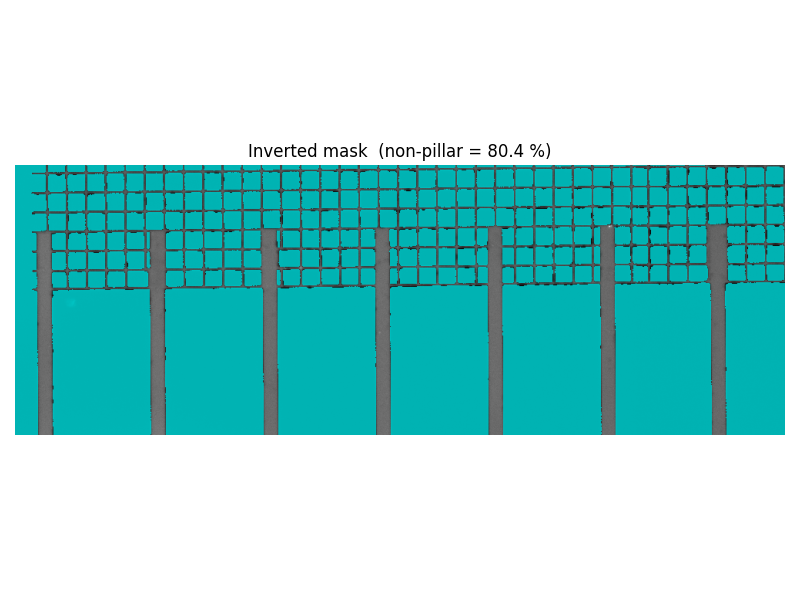

In [138]:
# ── Inverted mask: everything that is NOT a pillar ────────────────────────────
binary_inv = ~binary
from skimage.measure import label, regionprops

# labeled = label(binary_inv)
# regions = regionprops(labeled)
# if regions:
#     largest = min(regions, key=lambda r: r.area)
#     binary_inv = binary_inv.copy()
#     binary_inv[labeled == largest.label] = 0

inv_fraction = binary_inv.mean()
print(f"Inverted mask coverage : {inv_fraction * 100:.2f} %  "
      f"(original pillar mask was {pillar_fraction * 100:.2f} %)")

# ── Overlay on image (cyan tint on non-pillar regions) ────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

overlay_inv = np.stack([img_disp, img_disp, img_disp], axis=-1).astype(float)
overlay_inv[binary_inv, 0] = 0.0
overlay_inv[binary_inv, 1] = overlay_inv[binary_inv, 1] * 0.3 + 0.7
overlay_inv[binary_inv, 2] = overlay_inv[binary_inv, 2] * 0.3 + 0.7

ax.imshow(np.clip(overlay_inv, 0, 1))
ax.set_title(f"Inverted mask  (non-pillar = {inv_fraction*100:.1f} %)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Create Pillar Training Data

Saves **single-channel brightfield** patches + binary pillar masks to a dedicated dataset.  
Re-running is idempotent (existing patches are skipped); changing the CZI file or ROI appends new patches.

Input image shape : (350, 1000)  (brightfield ch0)
Mask shape        : (350, 1000)  (pillar fraction = 19.6%)

Source            : ICP16-03_pillar_ch0_t5
Candidate patches : 6 signal  +  0 bg kept  (from 0 bg candidates)
Saved             : 6   Skipped (already exist): 0
Dataset total     : 570 patches  →  /Users/bisot/Documents/PostDoc2/training_data_pillars


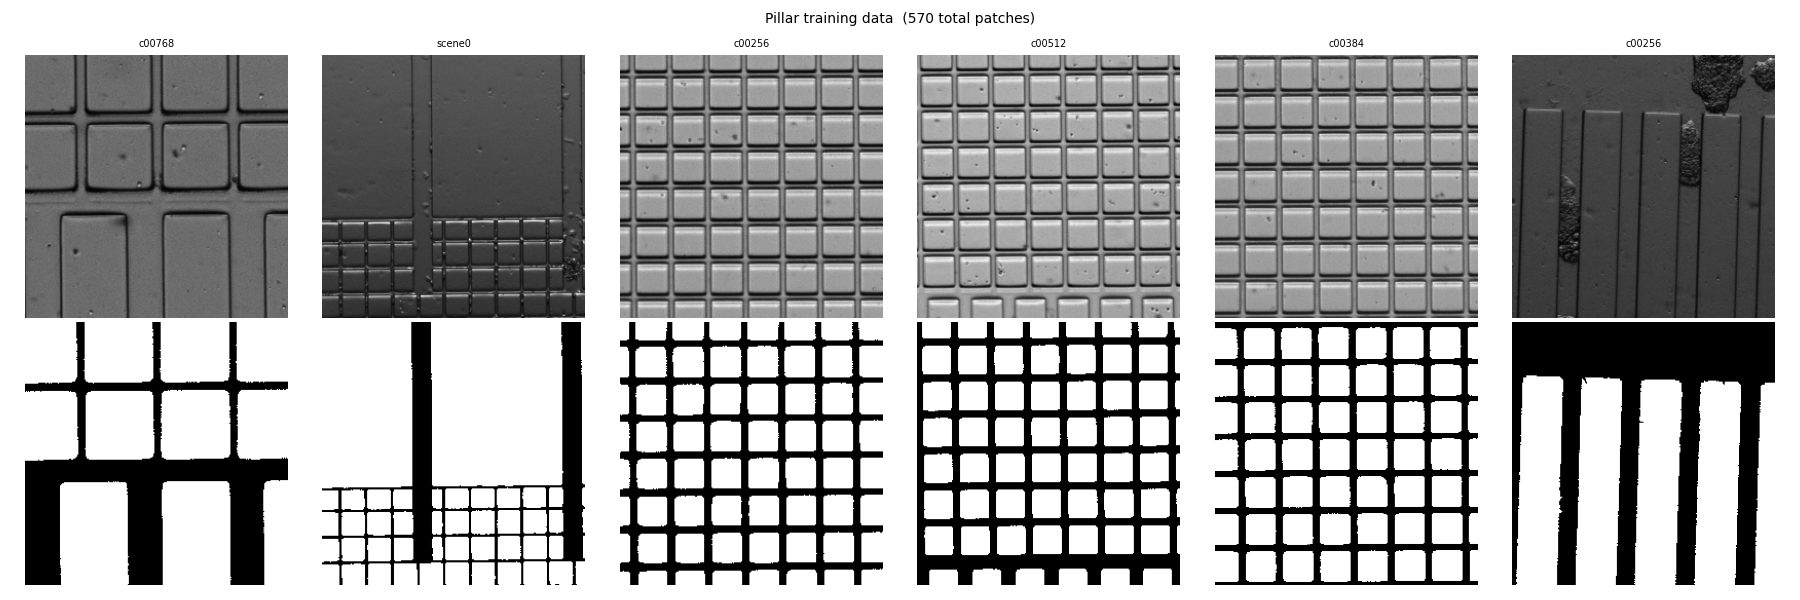

In [139]:
import os
import tifffile
import random

# ── Training data parameters ─────────────────────────────────────────────────
PILLAR_DATA_DIR     = "/Users/bisot/Documents/PostDoc2/training_data_pillars"
PATCH_SIZE_PX       = 256    # patch side length in pixels (square)
PATCH_STRIDE_PX     = 128    # stride (50 % overlap)
MIN_SIGNAL_FRACTION = 0.0   # discard patches with < 1 % pillar pixels
BALANCE_BACKGROUND  = True   # keep at most as many bg patches as signal patches
SKIP_IF_EXISTS      = True   # idempotent: skip existing files
channel_BF = 2
img_raw, img_disp = get_frame(czi, time, channel_BF, gamma=1, stretch_min=1, stretch_max=99.5,scene=scene)
img_raw  = select_roi(img_raw.astype(float))
img_disp = select_roi(img_disp)

img_norm = exposure.rescale_intensity(img_raw, out_range=(0.0, 1.0))
os.makedirs(os.path.join(PILLAR_DATA_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(PILLAR_DATA_DIR, "masks"),  exist_ok=True)

# ── Use brightfield (channel 0) normalised image as input ─────────────────────
# img_norm is already the normalised brightfield ROI from the thresholding cell.
# binary is the pillar mask from that same cell.
print(f"Input image shape : {img_norm.shape}  (brightfield ch{channel})")
print(f"Mask shape        : {binary.shape}  (pillar fraction = {pillar_fraction*100:.1f}%)")

# ── Unique source tag ─────────────────────────────────────────────────────────
source_tag = f"{czi_path.stem}_pillar_ch{channel}_t{time}"

# ── Patch extraction ──────────────────────────────────────────────────────────
patches_signal, patches_bg = [], []

for r in range(0, H - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
    for c in range(0, W - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
        img_patch  = img_norm[r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX].astype(np.float32)
        mask_patch = binary_inv  [r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX].astype(np.uint8)
        frac       = mask_patch.mean()
        name       = f"{source_tag}_r{r:05d}_c{c:05d}_scene{scene}"
        if frac >= MIN_SIGNAL_FRACTION:
            patches_signal.append((img_patch, mask_patch, name))
        else:
            patches_bg.append((img_patch, mask_patch, name))

# Balance background patches ───────────────────────────────────────────────────
if BALANCE_BACKGROUND and patches_bg:
    rng  = np.random.default_rng(seed=42)
    n_bg = min(len(patches_bg), max(len(patches_signal), 1))
    idx  = rng.choice(len(patches_bg), size=n_bg, replace=False)
    patches_bg_kept = [patches_bg[i] for i in idx]
else:
    patches_bg_kept = patches_bg

all_patches = patches_signal + patches_bg_kept

# ── Save ──────────────────────────────────────────────────────────────────────
saved, skipped = 0, 0
for img_patch, mask_patch, name in all_patches:
    img_path  = os.path.join(PILLAR_DATA_DIR, "images", f"{name}.tif")
    mask_path = os.path.join(PILLAR_DATA_DIR, "masks",  f"{name}.tif")
    if SKIP_IF_EXISTS and os.path.exists(img_path):
        skipped += 1
        continue
    tifffile.imwrite(img_path,  img_patch)   # (H, W) float32 — single channel
    tifffile.imwrite(mask_path, mask_patch)  # (H, W) uint8
    saved += 1

# ── Report ────────────────────────────────────────────────────────────────────
total = len([f for f in os.listdir(os.path.join(PILLAR_DATA_DIR, "images")) if f.endswith(".tif")])
print(f"\nSource            : {source_tag}")
print(f"Candidate patches : {len(patches_signal)} signal  +  {len(patches_bg_kept)} bg"
      f" kept  (from {len(patches_bg)} bg candidates)")
print(f"Saved             : {saved}   Skipped (already exist): {skipped}")
print(f"Dataset total     : {total} patches  →  {PILLAR_DATA_DIR}")

# ── Preview ───────────────────────────────────────────────────────────────────
img_dir  = os.path.join(PILLAR_DATA_DIR, "images")
mask_dir = os.path.join(PILLAR_DATA_DIR, "masks")
all_names = sorted(f for f in os.listdir(img_dir) if f.endswith(".tif"))
n_show   = min(6, len(all_names))
sample   = random.sample(all_names, n_show)

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i, fname in enumerate(sample):
    img_p  = tifffile.imread(os.path.join(img_dir,  fname))
    mask_p = tifffile.imread(os.path.join(mask_dir, fname))

    axes[0, i].imshow(img_p, cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(fname.rsplit("_", 2)[-1].replace(".tif", ""), fontsize=7)
    axes[0, i].axis("off")

    axes[1, i].imshow(mask_p, cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Brightfield", fontsize=9)
axes[1, 0].set_ylabel("Pillar mask", fontsize=9)
plt.suptitle(f"Pillar training data  ({len(all_names)} total patches)", fontsize=10)
plt.tight_layout()
plt.show()

## U-Net Training — Pillar Segmentation

Single-channel brightfield U-Net for binary pillar segmentation.

| Detail | Value |
|--------|-------|
| **Input** | `(1, H, W)` single-channel brightfield patch |
| **Output** | `(1, H, W)` sigmoid probability map |
| **Loss** | 0.5 × BCE + 0.5 × Dice |
| **Augmentation** | flips, 90° rotations, brightness / contrast jitter, Gaussian noise |
| **Downscaling** | optional `DOWNSCALE_FACTOR` — set to 2 to halve patch resolution (pillars are large structures) |

With only a handful of training patches, aggressive augmentation is critical.  
Run the *model definition* cell once, then the *training* cell (it resumes from checkpoint).

In [140]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize, rotate

# ─────────────────────────────────────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────────────────────────────────────
DOWNSCALE_FACTOR = 1        # 1 = no downscaling; 2 = patches become 128×128

# ─────────────────────────────────────────────────────────────────────────────
# Building block
# ─────────────────────────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

# ─────────────────────────────────────────────────────────────────────────────
# U-Net  — feature list sized for pillar structures
# Pillars are ~30-40 µm ≈ 20-30 px → well captured by a 4-level encoder
# (receptive field covers multiple pillars at the deepest level)
# ─────────────────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1,
                 features=(32, 64, 128, 256)):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.downs     = nn.ModuleList()
        self.ups_trans = nn.ModuleList()
        self.ups_conv  = nn.ModuleList()

        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat))
            ch = feat

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feat in reversed(features):
            self.ups_trans.append(nn.ConvTranspose2d(feat * 2, feat, 2, stride=2))
            self.ups_conv.append(DoubleConv(feat * 2, feat))

        self.final = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for i, (up_t, up_c) in enumerate(zip(self.ups_trans, self.ups_conv)):
            x = up_t(x)
            s = skips[-(i + 1)]
            if x.shape != s.shape:
                x = F.interpolate(x, size=s.shape[2:])
            x = torch.cat([s, x], dim=1)
            x = up_c(x)
        return self.final(x)

# ─────────────────────────────────────────────────────────────────────────────
# Dataset with rich augmentation
# ─────────────────────────────────────────────────────────────────────────────
class PillarDataset(Dataset):
    """
    Single-channel (H,W) brightfield images + binary masks.
    Augmentations applied jointly to image & mask:
      • random horizontal / vertical flip
      • random 90° rotation (k ∈ {0,1,2,3})
      • brightness shift  (additive, image only)
      • contrast scale     (multiplicative, image only)
      • Gaussian noise     (image only)
    Optional spatial downscaling by `downscale`.
    """
    def __init__(self, images_dir, masks_dir, augment=True, downscale=1):
        self.images_dir = images_dir
        self.masks_dir  = masks_dir
        self.names      = sorted(f for f in os.listdir(images_dir) if f.endswith(".tif"))
        self.augment    = augment
        self.downscale  = downscale

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        fname    = self.names[idx]
        img_arr  = tifffile.imread(os.path.join(self.images_dir, fname)).astype(np.float32)
        mask_arr = tifffile.imread(os.path.join(self.masks_dir,  fname)).astype(np.float32)

        # Optional downscale
        if self.downscale > 1:
            h, w = img_arr.shape
            new_h, new_w = h // self.downscale, w // self.downscale
            img_arr  = resize(img_arr,  (new_h, new_w), preserve_range=True, anti_aliasing=True).astype(np.float32)
            mask_arr = resize(mask_arr, (new_h, new_w), preserve_range=True, order=0).astype(np.float32)
            mask_arr = (mask_arr > 0.5).astype(np.float32)

        img_t  = torch.from_numpy(img_arr).unsqueeze(0)   # (1, H, W)
        mask_t = torch.from_numpy(mask_arr).unsqueeze(0)   # (1, H, W)

        if self.augment:
            # ── Spatial augmentation (applied to both) ───────────────────
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [2])       # horizontal flip
                mask_t = torch.flip(mask_t, [2])
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [1])       # vertical flip
                mask_t = torch.flip(mask_t, [1])
            k = int(torch.randint(0, 4, (1,)))
            img_t  = torch.rot90(img_t,  k, [1, 2])
            mask_t = torch.rot90(mask_t, k, [1, 2])
            # ── Random arbitrary rotation (e.g., ±45°) ──────────────────
            # ── Random arbitrary rotation (e.g., ±45°) ──────────────────
            angle = (torch.rand(1) * 90 - 45).item()  # random angle ∈ [-45°, +45°]
            img_t  = torch.from_numpy(
                rotate(img_t.squeeze(0).numpy(), angle, order=1, preserve_range=True)
            ).float().unsqueeze(0)
            mask_t = torch.from_numpy(
                rotate(mask_t.squeeze(0).numpy(), angle, order=0, preserve_range=True)
            ).float().unsqueeze(0)

            # ── Photometric augmentation (image only) ────────────────────
            # Brightness shift  ∈ [-0.1, +0.1]
            img_t = img_t + (torch.rand(1) * 0.2 - 0.1)
            # Contrast scale ∈ [0.8, 1.2]
            img_t = img_t * (0.8 + torch.rand(1) * 0.4)
            # Gaussian noise σ ∈ [0, 0.03]
            sigma = torch.rand(1) * 0.03
            img_t = img_t + torch.randn_like(img_t) * sigma
            # Clamp back to valid range
            img_t = img_t.clamp(0.0, 1.0)

        return img_t, mask_t

# ─────────────────────────────────────────────────────────────────────────────
# Sanity check
# ─────────────────────────────────────────────────────────────────────────────
_ds = PillarDataset(
    os.path.join(PILLAR_DATA_DIR, "images"),
    os.path.join(PILLAR_DATA_DIR, "masks"),
    augment=False,
    downscale=DOWNSCALE_FACTOR,
)
_img0, _mask0 = _ds[0]
print(f"Dataset size     : {len(_ds)} patches")
print(f"Image shape      : {tuple(_img0.shape)}   (patch = {_img0.shape[1]}×{_img0.shape[2]} px)")
print(f"Mask  shape      : {tuple(_mask0.shape)}")
print(f"Downscale factor : {DOWNSCALE_FACTOR}×")

device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Device           : {device}")

model = UNet(in_channels=1, out_channels=1, features=(32, 64, 128, 256)).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net parameters : {n_params:,}")

Dataset size     : 570 patches
Image shape      : (1, 256, 256)   (patch = 256×256 px)
Mask  shape      : (1, 256, 256)
Downscale factor : 1×
Device           : mps
U-Net parameters : 7,762,465


In [ ]:
import torch.optim as optim

# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPOCHS    = 40          # more epochs because dataset is tiny
BATCH_SIZE  = 4
LR          = 1e-4
VAL_SPLIT   = 0.2
MODEL_SAVE  = os.path.join(PILLAR_DATA_DIR, "unet_pillar_newchip.pth")

# ── Dataset split ─────────────────────────────────────────────────────────────
full_ds = PillarDataset(
    os.path.join(PILLAR_DATA_DIR, "images"),
    os.path.join(PILLAR_DATA_DIR, "masks"),
    augment=True,
    downscale=DOWNSCALE_FACTOR,
)
n_val   = max(1, int(len(full_ds) * VAL_SPLIT))
n_train = len(full_ds) - n_val
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)
val_ds.dataset.augment = False   # no augmentation for validation

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
print(f"Train : {n_train} patches   Val : {n_val} patches")

# ── Model, optimiser, scheduler ───────────────────────────────────────────────
model     = UNet(in_channels=1, out_channels=1, features=(32, 64, 128, 256)).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

start_epoch = 1
if os.path.exists(MODEL_SAVE):
    model.load_state_dict(torch.load(MODEL_SAVE, map_location=device, weights_only=True))
    print(f"Resumed from checkpoint: {MODEL_SAVE}")

# ── Loss: 0.5 BCE + 0.5 Dice ─────────────────────────────────────────────────
def dice_loss(logits, target, eps=1e-6):
    pred  = torch.sigmoid(logits)
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return 1 - (2 * inter + eps) / (union + eps)

def criterion(logits, target):
    bce  = F.binary_cross_entropy_with_logits(logits, target)
    dice = dice_loss(logits, target).mean()
    return 0.5 * bce + 0.5 * dice

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val = float("inf")

for epoch in range(start_epoch, N_EPOCHS + 1):
    # --- Train ---
    model.train()
    full_ds.augment = True                       # re-enable (disabled for val above)
    t_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_loader)

    # --- Validate ---
    model.eval()
    full_ds.augment = False
    v_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            v_loss += criterion(model(imgs), masks).item()
    v_loss /= len(val_loader)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        torch.save(model.state_dict(), MODEL_SAVE)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS}  train={t_loss:.4f}  val={v_loss:.4f}  best={best_val:.4f}")

print(f"\nBest model saved → {MODEL_SAVE}")

# ── Loss curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="train")
ax.plot(val_losses,   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE + Dice loss")
ax.legend()
ax.set_title("U-Net pillar training")
plt.tight_layout()
plt.show()

Train : 456 patches   Val : 114 patches
Epoch   1/40  train=0.4909  val=0.4591  best=0.4591


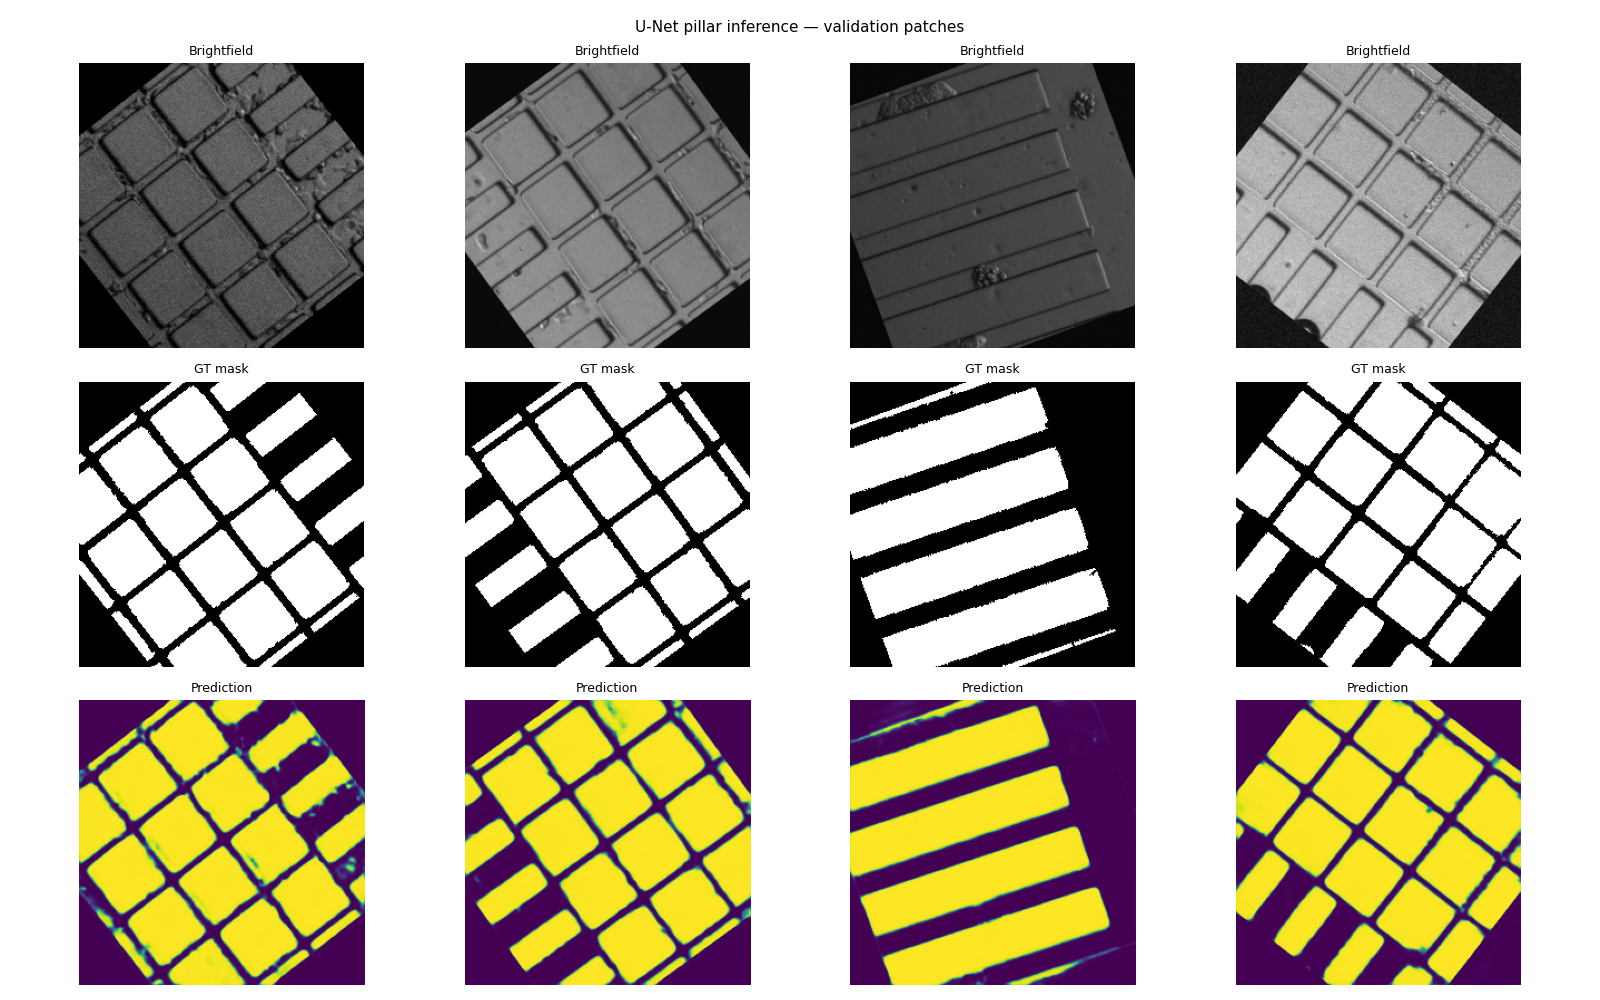

In [99]:
# ── Inference preview on validation patches ───────────────────────────────────
model.eval()
model.load_state_dict(torch.load(MODEL_SAVE, map_location=device, weights_only=True))

n_show = min(4, n_val)
val_imgs, val_masks = [], []
for i in range(n_show):
    img_t, mask_t = val_ds[i]
    val_imgs.append(img_t)
    val_masks.append(mask_t)

imgs_batch  = torch.stack(val_imgs).to(device)
masks_batch = torch.stack(val_masks)

with torch.no_grad():
    preds = torch.sigmoid(model(imgs_batch)).cpu().numpy()[:, 0]   # (N, H, W)

imgs_np  = imgs_batch.cpu().numpy()[:, 0]     # (N, H, W)  single channel
masks_np = masks_batch.numpy()[:, 0]           # (N, H, W)

fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 10))
if n_show == 1:
    axes = axes[:, np.newaxis]
for i in range(n_show):
    axes[0, i].imshow(imgs_np[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("Brightfield", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(masks_np[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("GT mask", fontsize=9)
    axes[1, i].axis("off")

    axes[2, i].imshow(preds[i], cmap="viridis", vmin=0, vmax=1)
    axes[2, i].set_title(f"Prediction", fontsize=9)
    axes[2, i].axis("off")

plt.suptitle("U-Net pillar inference — validation patches", fontsize=11)
plt.tight_layout()
plt.show()

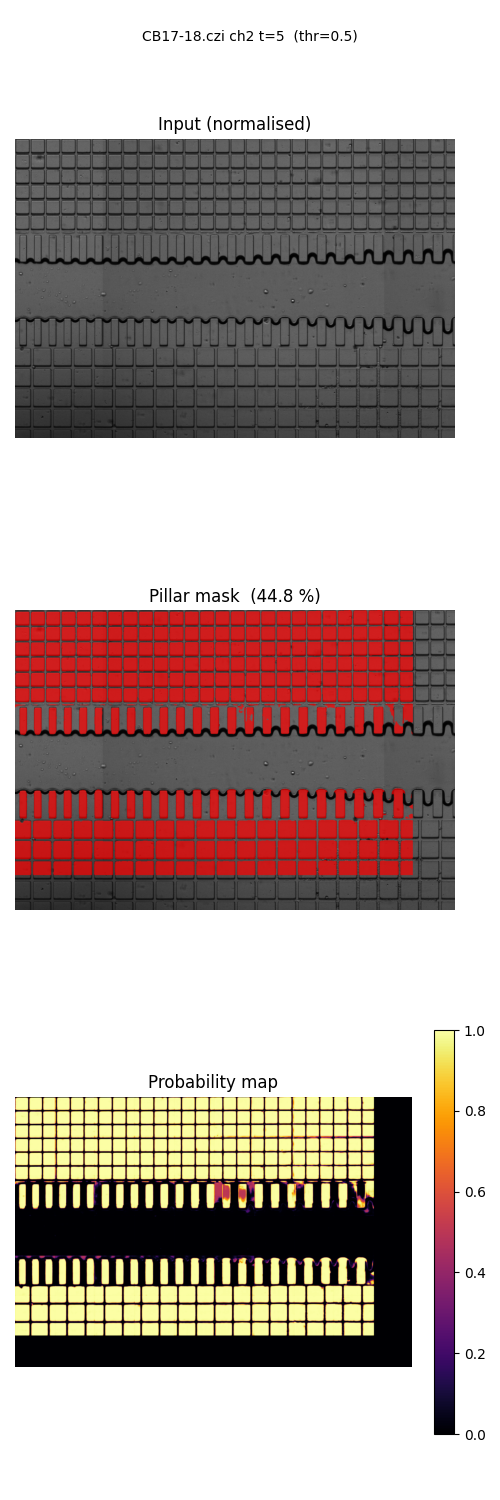

Pillar coverage: 44.78 %


In [106]:
def predict_pillars(
    image,
    model_path=None,
    threshold=0.5,
    patch_size=None,
    patch_stride=None,
    show_plot=True,
    title="Pillar prediction",
):
    """
    Run pillar U-Net inference on any 2-D image (numpy array).

    The image is normalised to [0, 1] internally — pass any dtype / range.

    Parameters
    ----------
    image : np.ndarray, shape (H, W)
        Single-channel brightfield image (any dtype, any value range).
    model_path : str or Path, optional
        Checkpoint path.  Defaults to the notebook's MODEL_SAVE.
    threshold : float
        Probability cutoff for the binary mask.
    patch_size : int, optional
        Sliding-window patch side.  Defaults to PATCH_SIZE_PX from training.
    patch_stride : int, optional
        Sliding-window stride.  Defaults to PATCH_STRIDE_PX from training.
    show_plot : bool
        If True, display a comparison figure.
    title : str
        Figure super-title.

    Returns
    -------
    dict  with keys
        'prob_map'     – (H, W) float32 probability map
        'pred_binary'  – (H, W) bool binary mask
        'img_norm'     – (H, W) float32 normalised input
        'coverage'     – float ∈ [0, 1]
    """
    _model_path  = model_path or MODEL_SAVE
    _patch_sz    = patch_size  or PATCH_SIZE_PX
    _patch_str   = patch_stride or PATCH_STRIDE_PX

    # ── Normalise to [0, 1] float32 ─────────────────────────────────────────
    img_norm = image.astype(np.float64)
    vmin, vmax = img_norm.min(), img_norm.max()
    if vmax - vmin > 0:
        img_norm = (img_norm - vmin) / (vmax - vmin)
    img_norm = img_norm.astype(np.float32)

    H_img, W_img = img_norm.shape

    # ── Load model ───────────────────────────────────────────────────────────
    _model = UNet(in_channels=1, out_channels=1, features=(32, 64, 128, 256)).to(device)
    _model.load_state_dict(torch.load(_model_path, map_location=device, weights_only=True))
    _model.eval()

    # ── Sliding-window inference ─────────────────────────────────────────────
    prob_sum = np.zeros((H_img, W_img), dtype=np.float32)
    count    = np.zeros((H_img, W_img), dtype=np.float32)

    with torch.no_grad():
        for r in range(0, H_img - _patch_sz + 1, _patch_str):
            for c in range(0, W_img - _patch_sz + 1, _patch_str):
                patch = img_norm[r:r+_patch_sz, c:c+_patch_sz]
                t = torch.from_numpy(patch[np.newaxis, np.newaxis]).to(device)  # (1,1,P,P)
                prob = torch.sigmoid(_model(t)).squeeze().cpu().numpy()
                prob_sum[r:r+_patch_sz, c:c+_patch_sz] += prob
                count   [r:r+_patch_sz, c:c+_patch_sz] += 1.0

    count    = np.where(count == 0, 1, count)
    prob_map = prob_sum / count
    pred_bin = prob_map >= threshold
    coverage = pred_bin.mean()

    # ── Visualisation ────────────────────────────────────────────────────────
    if show_plot:
        fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharex=True, sharey=True)

        axes[0].imshow(img_norm, cmap="gray", vmin=0, vmax=1)
        axes[0].set_title("Input (normalised)")

        ov = np.stack([img_norm]*3, axis=-1).copy()
        ov[pred_bin, 0] = ov[pred_bin, 0] * 0.3 + 0.7
        ov[pred_bin, 1] = ov[pred_bin, 1] * 0.3
        ov[pred_bin, 2] = ov[pred_bin, 2] * 0.3
        axes[1].imshow(np.clip(ov, 0, 1))
        axes[1].set_title(f"Pillar mask  ({coverage*100:.1f} %)")

        im = axes[2].imshow(prob_map, cmap="inferno", vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[2], fraction=0.046)
        axes[2].set_title("Probability map")

        for ax in axes:
            ax.axis("off")
        plt.suptitle(f"{title}  (thr={threshold})", fontsize=10)
        plt.tight_layout()
        plt.show()

    return {
        "prob_map":    prob_map,
        "pred_binary": pred_bin,
        "img_norm":    img_norm,
        "coverage":    coverage,
    }
def select_roi2(img):
#     roi, _ = get_roi_from_result(
#     result,
#     result['rotate_fn'](img) ,
#     region= "full",
#     pad_left_um=-1500.0,   # expand chip box leftward (µm)
#     pad_right_um=-3500.0,  # expand chip box rightward (µm)
#     pad_top_um=1300.0,    # pad above & below main channel centre (symmetric)
#     pad_bottom_um= 1300
# )
    return img
channel = 2
time = 5
img, _ = get_frame(czi,time,channel,gamma=0.45,stretch_min=stretch_min,stretch_max=stretch_max)
# ── Quick test on the current brightfield ROI ────────────────────────────────
res = predict_pillars(select_roi2(img), threshold=0.5, title=f"{czi_path.name} ch{channel} t={time}")
print(f"Pillar coverage: {res['coverage']*100:.2f} %")

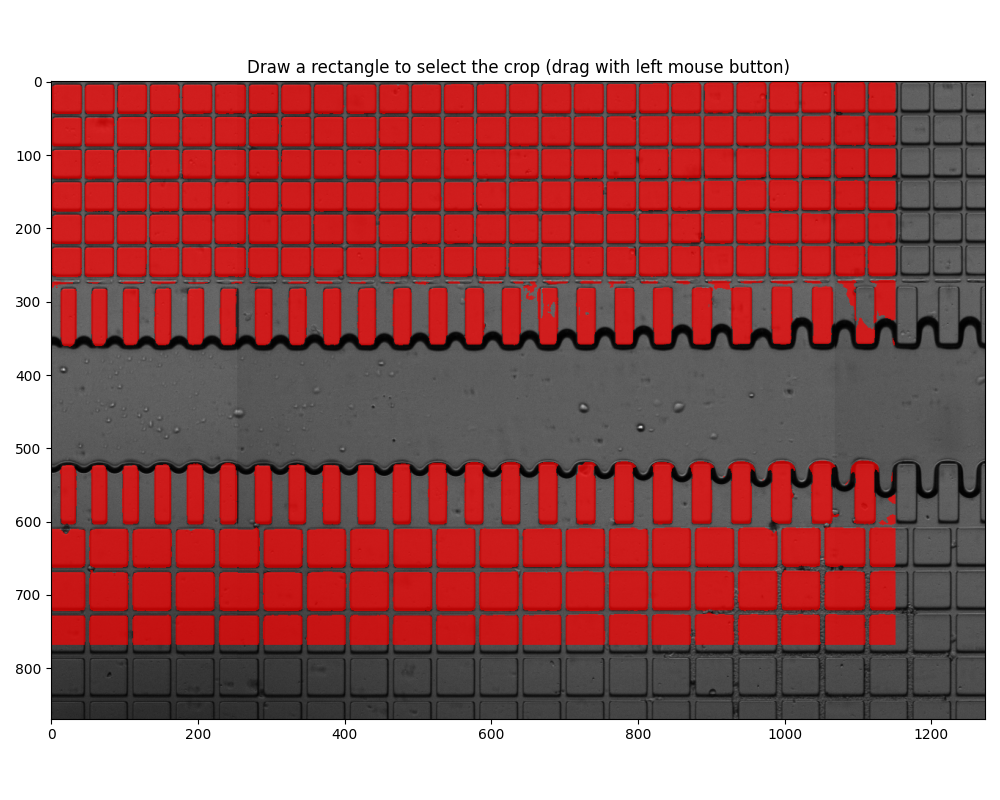

In [107]:
# ── Interactive crop selection on the predicted image ─────────────────────────
# Draw a rectangle on the figure; the selected coordinates are stored in
# `crop_coords` as (row_start, row_end, col_start, col_end).
from matplotlib.widgets import RectangleSelector
import matplotlib.patches as mpatches

crop_coords = {}   # will be filled by the selector callback

_img_for_crop = res["img_norm"]

fig_crop, ax_crop = plt.subplots(figsize=(10, 8))
_ov = np.stack([_img_for_crop]*3, axis=-1).copy()
_bin = res["pred_binary"]
_ov[_bin, 0] = _ov[_bin, 0] * 0.3 + 0.7
_ov[_bin, 1] = _ov[_bin, 1] * 0.3
_ov[_bin, 2] = _ov[_bin, 2] * 0.3
ax_crop.imshow(np.clip(_ov, 0, 1))
ax_crop.set_title("Draw a rectangle to select the crop (drag with left mouse button)")

def _on_select(eclick, erelease):
    c0, r0 = int(eclick.xdata),   int(eclick.ydata)
    c1, r1 = int(erelease.xdata), int(erelease.ydata)
    r0, r1 = min(r0, r1), max(r0, r1)
    c0, c1 = min(c0, c1), max(c0, c1)
    crop_coords.update(dict(r0=r0, r1=r1, c0=c0, c1=c1))
    print(f"Selected crop  rows {r0}:{r1}  cols {c0}:{c1}  "
          f"({r1-r0} × {c1-c0} px)")

_rs = RectangleSelector(
    ax_crop, _on_select,
    useblit=True,
    button=[1],
    minspanx=10, minspany=10,
    spancoords="pixels",
    interactive=True,
)
plt.tight_layout()
plt.show()

Crop shape : (457, 587)
Saved 6 new patches from crop  →  dataset now has 528 patches total


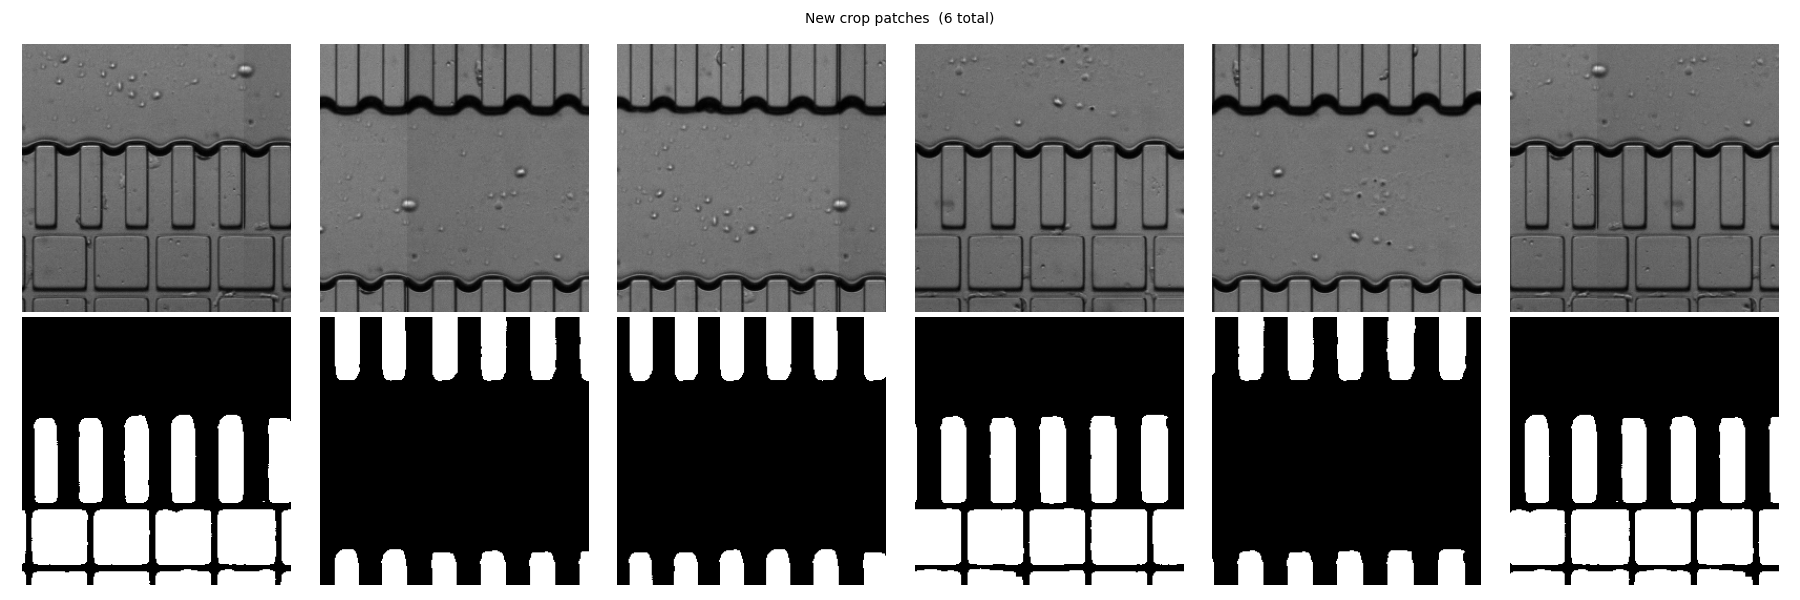

In [105]:
# ── Save cropped image + predicted mask to training dataset ───────────────────
# Requires `crop_coords` to be filled by the cell above.

assert crop_coords, "No crop selected — run the cell above and draw a rectangle first."

r0, r1 = crop_coords["r0"], crop_coords["r1"]
c0, c1 = crop_coords["c0"], crop_coords["c1"]

crop_img  = res["img_norm"][r0:r1, c0:c1]      # float32 normalised brightfield
crop_mask = res["pred_binary"][r0:r1, c0:c1].astype(np.uint8)   # binary uint8

print(f"Crop shape : {crop_img.shape}")

# ── Tile the crop into PATCH_SIZE_PX patches ──────────────────────────────────
source_tag_crop = f"{czi_path.stem}_crop_r{r0}c{c0}_ch{channel}_t{time}"
H_c, W_c = crop_img.shape

saved_crop = 0
for r in range(0, H_c - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
    for c in range(0, W_c - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
        img_patch  = crop_img [r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX].astype(np.float32)
        mask_patch = crop_mask[r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX]
        name       = f"{source_tag_crop}_r{r:05d}_c{c:05d}"

        img_out  = os.path.join(PILLAR_DATA_DIR, "images", f"{name}.tif")
        mask_out = os.path.join(PILLAR_DATA_DIR, "masks",  f"{name}.tif")

        if SKIP_IF_EXISTS and os.path.exists(img_out):
            continue
        tifffile.imwrite(img_out,  img_patch)
        tifffile.imwrite(mask_out, mask_patch)
        saved_crop += 1

total_now = len([f for f in os.listdir(os.path.join(PILLAR_DATA_DIR, "images")) if f.endswith(".tif")])
print(f"Saved {saved_crop} new patches from crop  →  dataset now has {total_now} patches total")

# ── Quick preview of a few saved crop patches ─────────────────────────────────
crop_names = sorted(f for f in os.listdir(os.path.join(PILLAR_DATA_DIR, "images"))
                    if f.startswith(source_tag_crop) and f.endswith(".tif"))
n_show = min(6, len(crop_names))
if n_show:
    sample = random.sample(crop_names, n_show)
    fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
    for i, fname in enumerate(sample):
        ip = tifffile.imread(os.path.join(PILLAR_DATA_DIR, "images", fname))
        mp = tifffile.imread(os.path.join(PILLAR_DATA_DIR, "masks",  fname))
        axes[0, i].imshow(ip, cmap="gray", vmin=0, vmax=1); axes[0, i].axis("off")
        axes[1, i].imshow(mp, cmap="gray", vmin=0, vmax=1); axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Brightfield", fontsize=9)
    axes[1, 0].set_ylabel("Pred mask",   fontsize=9)
    plt.suptitle(f"New crop patches  ({len(crop_names)} total)", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No new patches to preview (all already existed).")